# K-Fold Cross Validation

## Step-by-step

1. **Data Splitting**: The dataset is divided into $k$ equal folds.  
2. **Model Training**: For each iteration (a total of $k$ times):  
   - $k-1$ folds are used for training.  
   - The remaining fold is used for testing the model.  
3. **Error Calculation**: After $k$ iterations, we obtain *k* performance metrics (e.g., accuracy, MSE, etc.).  
4. **Final Evaluation**: The final model performance is determined by taking the average of all $k$ metric scores.

## How does K-Fold cross validation work?

Folds:

1. [V][ ][ ][ ][ ][ ][ ][ ][ ][ ] -> Metrics(V)
2. [ ][V][ ][ ][ ][ ][ ][ ][ ][ ] -> Metrics(V)
3. [ ][ ][V][ ][ ][ ][ ][ ][ ][ ] -> Metrics(V)
4. [ ][ ][ ][V][ ][ ][ ][ ][ ][ ] -> Metrics(V)
5. [ ][ ][ ][ ][V][ ][ ][ ][ ][ ] -> Metrics(V)
6. [ ][ ][ ][ ][ ][V][ ][ ][ ][ ] -> Metrics(V)
7. [ ][ ][ ][ ][ ][ ][V][ ][ ][ ] -> Metrics(V)
8. [ ][ ][ ][ ][ ][ ][ ][V][ ][ ] -> Metrics(V)
9. [ ][ ][ ][ ][ ][ ][ ][ ][V][ ] -> Metrics(V)
10. [ ][ ][ ][ ][ ][ ][ ][ ][ ][V] -> Metrics(V)

V - validation data\
[ ] - training data\
Metrics(V) - score

Final score = mean([Metrics(V)])

## Dataset

Have a quick look at the dataset.

In [1]:
%cat ../00_data/Social_Network_Ads.csv | head

Age,EstimatedSalary,Purchased
19,19000,0
35,20000,0
26,43000,0
27,57000,0
19,76000,0
27,58000,0
27,84000,0
32,150000,1
25,33000,0


In [2]:
%cat ../00_data/Social_Network_Ads.csv | tail

48,33000,1
47,23000,1
45,45000,1
60,42000,1
39,59000,0
46,41000,1
51,23000,1
50,20000,1
36,33000,0
49,36000,1

## Load the libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load data

In [4]:
df = pd.read_csv('../00_data/Social_Network_ads.csv', decimal='.', sep=',')

df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [5]:
df.shape

(400, 3)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [7]:
np.sum(df.isna(), axis=0)

Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

## Target Variable and Features

+ Target Variable: `Purchased`
+ Features:
    + `Age`
    + `EstimatedSalary`


In [8]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [9]:
X[:10, :]

array([[    19,  19000],
       [    35,  20000],
       [    26,  43000],
       [    27,  57000],
       [    19,  76000],
       [    27,  58000],
       [    27,  84000],
       [    32, 150000],
       [    25,  33000],
       [    35,  65000]])

In [10]:
y[:10]

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0])

## Splitting the dataset into the Training set and Test set

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

## Fit and train the model

In [12]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score

# the model
pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model",  SVC(kernel='rbf', random_state=42))
    ]
)

# train the model
pipeline.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()), ('model', SVC(random_state=42))])

## Predicting the Testing set results

In [13]:
# test the model
y_pred = pipeline.predict(X_test)

## Evaluate the performance of the model

### Confusion matrix

The confusion matrix shows how many mistakes and correct predictions are model made.

In [14]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[64  4]
 [ 3 29]]


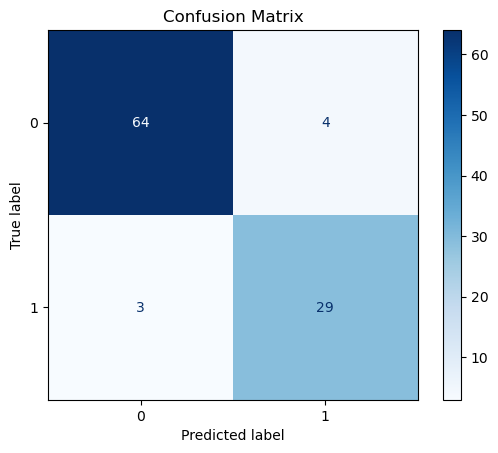

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=pipeline.classes_)
disp.plot(cmap=plt.cm.Blues,
         colorbar=True)
plt.title("Confusion Matrix")
plt.show()

**Interpretation:**

$$
\begin{bmatrix}
True Negative & False Positive\\
False Negative & True Positive
\end{bmatrix}
$$

### Accuracy score

The accuracy score measures the percentage of correct predictions made by a classification model over the total number of predictions.

In [16]:
from sklearn.metrics import accuracy_score

# cross validation on training set
cv = KFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(estimator=pipeline, X=X_train, y=y_train, cv=cv, scoring="accuracy")

# accuracy on the test set
ac = accuracy_score(y_test, y_pred)

print(f"Mean accuracy on cross validation: {cv_scores.mean():.2f}")
print(f'Accuracy on test set: {ac:.2f}')

Mean accuracy on cross validation: 0.90
Accuracy on test set: 0.93


## Combining grid search (hyperparameter tuning) and Cross Validation

In [17]:
# check class balance
pd.Series(y_train).value_counts(normalize=True) * 100

0    63.0
1    37.0
Name: proportion, dtype: float64

In [18]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

pipe = Pipeline(
    steps=[
        ("scaler", StandardScaler()), 
        ("svc", SVC(random_state=42))
    ]
)

param_grid = [
    # linear params
    {'svc__kernel': ['linear'], 
     'svc__C': [0.1, 0.25, 0.5, 1.0, 10.0, 100.0], 
     'svc__class_weight': [None, 'balanced']},
    # rbf params
    {'svc__kernel': ['rbf'], 
     'svc__C': [0.1, 0.25, 0.5, 1.0, 10.0, 100.0], 
     'svc__gamma': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0], 
     'svc__class_weight': [None, 'balanced']}
]

# hyperparameter tuning on training set
grid_search = GridSearchCV(pipe, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# best params
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.2f}")

# using the best model on test set
y_pred = grid_search.best_estimator_.predict(X_test)
print(f'Accuracy on test set: {accuracy_score(y_test, y_pred):.2f}')


Best Parameters: {'svc__C': 0.25, 'svc__class_weight': 'balanced', 'svc__gamma': 0.6, 'svc__kernel': 'rbf'}
Best Cross-Validation Accuracy: 0.91
Accuracy on test set: 0.93
